In [1]:
import glob
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import rioxarray  # noqa: F401  (registers .rio accessor)
import xarray as xr
import matplotlib.pyplot as plt
from rasterio.warp import Resampling, reproject
from shapely.geometry import box
import math

# --------------------------
# Configuration — edit these
# --------------------------
CRS_TARGET = "EPSG:27700"

DEM_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/dem/"
CSV_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/"
NETCDF_DIR = "/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/"
SOIL_TEXTURE_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
POROSITY_CSV = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/SoilTexture/USDA_soil_texture_effective_porosity.csv"
SOILS_LOOKUP_CSV = "../../Data/Rawls_soil_lookup.csv"  # USDA_soil, Hydraulic_conductivity

from functions import filter_closer_to_catchment_xr_bounds
from helper_functions import *

from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS
event_details_fp = 'EventDetails'

In [2]:
rainfall_events_all_df = pd.read_pickle(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/{event_details_fp}/all_catchments.pkl")

23 doesn't exist
Zero-porosity pixels: 63161
Zero-porosity pixels NOT covered by dem_mask_bool: 63161


Text(0.5, 1.0, 'Zero-porosity pixels not excluded by DEM mask')

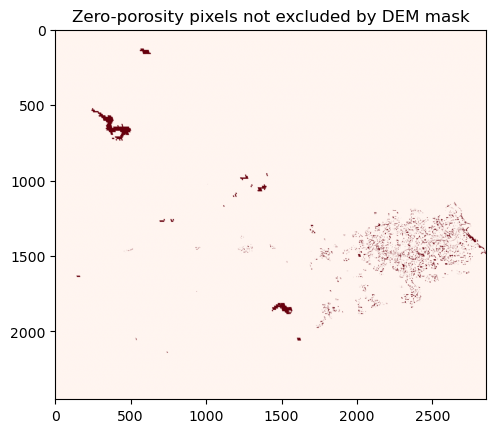

In [9]:
ha_num = '23' 
TARGET_HA = '23' 
boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(TARGET_HA)]
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
catchment_name = CATCHMENT_LOOKUP_DICT[TARGET_HA]
target_has = [TARGET_HA]


# --------------------------
dem_files = [p for p in glob.glob(os.path.join(DEM_DIR, "*.tif"))
    if extract_ha_num(p) in target_has]
if not dem_files:
    raise FileNotFoundError(f"No DEM found for HA_NUM {TARGET_HA} in {DEM_DIR}")

dem_path = dem_files[0] 
ha_num = extract_ha_num(dem_path) 
with rasterio.open(dem_path) as dem: 
    dem_info = {"bounds": box(*dem.bounds),"transform": dem.transform,"crs": dem.crs,"width": dem.width, 
                "height": dem.height,"mask": dem.read(1), } 
    dem_mask_bool = dem_info["mask"] == -9999 
    
soil_grids = load_soil_grids(POROSITY_CSV, SOILS_LOOKUP_CSV, SOIL_TEXTURE_DIR, target_has) 
porosity_data = soil_grids[ha_num]["porosity"] 
n_zero_porosity = int((porosity_data == 0).sum()) 
print(f"Zero-porosity pixels: {n_zero_porosity}") 

# Are these being caught by dem_mask_bool already, or slipping through? 
zero_por_mask = porosity_data == 0 
print("Zero-porosity pixels NOT covered by dem_mask_bool:", int((zero_por_mask & ~dem_mask_bool).sum())) 
# Where are they spatially — coastline/water, or scattered inland? # (quick visual check) 

plt.imshow(zero_por_mask & ~dem_mask_bool, cmap="Reds") 
plt.title("Zero-porosity pixels not excluded by DEM mask") 

In [14]:
target_has = [TARGET_HA]
events_this_catchment = rainfall_events_all_df[rainfall_events_all_df['catchment_num'] == TARGET_HA]

lu_data = soil_grids[ha_num]["lu"]
hc_data = soil_grids[ha_num]["hc"]
porosity_data = soil_grids[ha_num]["porosity"]
fumax_data = porosity_data * lu_data
print(f"Porosity range: {np.nanmin(porosity_data):.3f} to {np.nanmax(porosity_data):.3f}")
print(f"Lu range: {np.nanmin(lu_data):.3f} to {np.nanmax(lu_data):.3f} m")

# --------------------------
# 3. Aggregate static soil variables to 5 km (porosity + Lu grids (aligned to the same soil-texture raster))
# --------------------------
# Get one soil_moisture file for using to define shape 
soil_moisture_5km_fp = '/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_10/r001i1p02242_20651201-20661130_mrso.nc'
with xr.open_dataset(soil_moisture_5km_fp) as soil_moisture_5km:
    grav_clipped = filter_closer_to_catchment_xr_bounds(
            soil_moisture_5km.isel(time=0), CATCHMENT_POLY)["moisture_content_of_soil_layer"]
    grav_clipped = grav_clipped.rio.write_crs("EPSG:27700")

lu_5km = aggregate_to_coarse_grid(lu_data, dem_info, grav_clipped)
lu_5km_da = grav_clipped.copy(data=lu_5km.reshape(np.squeeze(grav_clipped.values).shape))
lu_5km_da.name = "lu_mean_5km"  

hc_5km = aggregate_to_coarse_grid(hc_data, dem_info, grav_clipped)
hc_5km_da = grav_clipped.copy(data=hc_5km.reshape(np.squeeze(grav_clipped.values).shape))
hc_5km_da.name = "hc_mean_5km"      

fumax_5km = aggregate_to_coarse_grid(fumax_data, dem_info, grav_clipped)
fumax_5km_da = grav_clipped.copy(data=fumax_5km.reshape(np.squeeze(grav_clipped.values).shape))
fumax_5km_da.name = "fumax_mean_5km"  

porosity_5km = aggregate_to_coarse_grid(porosity_data, dem_info, grav_clipped)
porosity_5km_da = grav_clipped.copy(data=porosity_5km.reshape(np.squeeze(grav_clipped.values).shape))
porosity_5km_da.name = "porosity_mean_5km"              


##############################################
### MAIN
##############################################

results_total = []
skip_HA = False
ENSEMBLE_STR = '01'
ENSEMBLE_INT = int(ENSEMBLE_STR.lstrip('0'))
ENSEMBLE = f"Ens_{ENSEMBLE_STR}"

# Get event data for this ensemble member
csv_dir = '/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/'
csv_path = csv_dir +  f'{catchment_name}_{ENSEMBLE_STR}_full_events_with_event_nums.csv'
events_df = pd.read_csv(csv_path)
# events_df = events_df[events_df['peaks']<130].copy()

# Get processed event data
events_this_catchment_this_ens = events_this_catchment[events_this_catchment['ens']==ENSEMBLE_STR].copy()
print(len(events_df), len(events_this_catchment_this_ens))

if not len(events_df) == len(events_this_catchment_this_ens):
    print("dataframes different lengths" )
    skip_HA = True

events_this_catchment_this_ens = events_this_catchment_this_ens.merge(
    events_df[["event_num", "start_month", "start_day", "start_indices"]],
    on="event_num",how="left",)

# --------------------------
# 4. Run the pipeline for each event, keeping intermediate arrays
# --------------------------
results = []
i = 0
row = events_this_catchment_this_ens.iloc[0]
year, month, day = int(row["start_year"]), int(row["start_month"]), int(row["start_day"])
event_num = int(row["event_num"])
start_index = int(row["start_indices"])

#################################################################################
#  Get soil moisture in kg/m2 for this catchment at 5km, then resample to 30m
#################################################################################

soil_moisture_5km_fp = find_matching_netcdf(os.path.join(NETCDF_DIR, ENSEMBLE), year, month, day)
if soil_moisture_5km_fp is None:
    print(f"Skipping event {event_num}: no matching NetCDF")

with xr.open_dataset(soil_moisture_5km_fp) as soil_moisture_5km:
    index = (start_index - 1) // 24
    # OLD APPROACH: NB: THIS IS WHAT WAS USED FOR RUNNING ALL OF THE OTHER CATCHMENTS EXCEPT 46 
    # grav_clipped = clip_gravitational(soil_moisture_5km.isel(time=index), "moisture_content_of_soil_layer", 
    #                                    dem_info["bounds"], CRS_TARGET)
    # NEW APPROACH: CHANGED BECAUSE FOR CATCHMWNT 46 OTHERWISE COORDINATES WERE BEING OFFSET 
    grav_clipped = filter_closer_to_catchment_xr_bounds(
            soil_moisture_5km.isel(time=index), CATCHMENT_POLY)["moisture_content_of_soil_layer"]
    grav_clipped = grav_clipped.rio.write_crs("EPSG:27700")

    # Pipeline 1 grid (soil-moisture/DEM-bounds clip)
    p1_x = grav_clipped.projection_x_coordinate.values[row["x_idx"]]
    p1_y = grav_clipped.projection_y_coordinate.values[row["y_idx"]]

    if row['x_coord'] != p1_x and row['y_coord'] != p1_y:
        print("Pipeline 1 peak coord:", p1_x, p1_y)
        print("x and y from dataframe", row['x_coord'], row['y_coord'])
        print(event_num)

    grav_30m_array = resample_to_30m_array(grav_clipped, dem_info)

#################################################################################
#  Convert to soil saturation (0-1) theta / theta_s (pre-clip)
#################################################################################        

with np.errstate(divide="ignore", invalid="ignore"):
    vol_sm_raw_new = ((grav_30m_array / 1000.0) / 0.225) / porosity_data
    vol_sm_raw_old = ((grav_30m_array / 1000.0)) / porosity_data

valid = ~dem_mask_bool & np.isfinite(vol_sm_raw_new)
n_valid = int(valid.sum())
n_over1 = int((vol_sm_raw_new[valid] > 1).sum()) if n_valid else 0
n_under0 = int((vol_sm_raw_new[valid] < 0).sum()) if n_valid else 0


Porosity range: 0.000 to 0.434
Lu range: 0.011 to 0.067 m
95 95


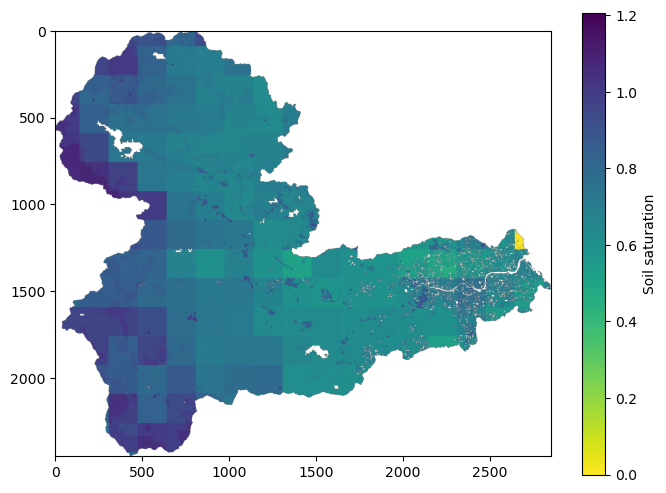

In [15]:
plot_data = vol_sm_raw_new.copy()

inf_mask = np.isinf(plot_data)
nan_mask = np.isnan(plot_data)

# plot_data[inf_mask] = 1.01

cmap = plt.cm.viridis_r.copy()
# cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.pcolormesh(np.ma.masked_where(nan_mask, plot_data), vmin=0, vmax=1.01, cmap=cmap)

# im = ax.imshow(np.ma.masked_where(nan_mask, plot_data), cmap=cmap) 
im = ax.imshow(plot_data, cmap=cmap) 

fig.colorbar(im, ax=ax, label="Soil saturation")

plt.show()

### Filtered to the catchment because porosity values are filtered to the catchment

In [28]:
ha_num = extract_ha_num(tif)
with rasterio.open('/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/soil_30m_23.tif') as src:
    data = src.read(1)
plt.pcolormesh(data)